In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
path = "../../CSVs/Bangladesh_2019_NSRDB_986494_OneAxis.csv"

df = pd.read_csv(
    path,
    skiprows=2,
    low_memory=False
)

print(df.shape)
display(df.head())

(8760, 2034)


,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,...,3.9550 um,3.9600 um,3.9650 um,3.9700 um,3.9750 um,3.9800 um,3.9850 um,3.9900 um,3.9950 um,4.0000 um
0,2019,1,1,0,0,11.6,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2019,1,1,1,0,13.2,17.0,98.0,21.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2019,1,1,2,0,15.7,80.0,464.0,196.0,0.0,...,5.250177,5.381783,5.506646,5.363013,5.059920,4.911362,5.015514,4.901602,4.694515,4.521171
3,2019,1,1,3,0,18.7,125.0,607.0,383.0,0.0,...,5.748244,5.823888,5.902234,5.793089,5.590908,5.481513,5.532466,5.442906,5.292155,5.169549
4,2019,1,1,4,0,22.1,146.0,708.0,543.0,0.0,...,5.650250,5.700525,5.757926,5.666630,5.513091,5.423911,5.450926,5.375887,5.254264,5.158478


In [6]:
print("========== BASIC DATA OVERVIEW ==========")
print("\n--- Dataset Shape ---")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isna().sum().sort_values(ascending=False))

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Numeric Summary ---")
numeric_df = df.select_dtypes(include="number")
if not numeric_df.empty:
    print(numeric_df.describe().T)
else:
    print("No numeric columns found.")


========== BASIC DATA OVERVIEW ==========

--- Dataset Shape ---
Rows: 8760
Columns: 2034

--- Column Names ---
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Dew Point', 'DHI', 'DNI', 'Fill Flag', 'GHI', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed', 'Si (BPR)', 'Si (Wacker)', 'Si (Eurosil)', 'GaAs (Bauhuis et al., 2009)', 'InGap (Gray, 2008)', 'InGap (McGambridge, 2011)', 'CdTe', 'Solar Azimuth Angle', 'Panel Tilt', 'Panel Azimuth Angle', '0.2800 um', '0.2805 um', '0.2810 um', '0.2815 um', '0.2820 um', '0.2825 um', '0.2830 um', '0.2835 um', '0.2840 um', '0.2845 um', '0.2850 um', '0.2855 um', '0.2860 um', '0.2865 um', '0.2870 um', '0.2875 um', '0.2880 um', '0.2885 um', '0.2890 um', '0.2895 um', '0.2900 um', '0.2905 um', '0.2910 um', '0.2915 um', '0.2920 um', '0.2925 um', '0.2930 um', '0.2935 um', '0.2940 um', '0.2945 um', '0.2950 um'

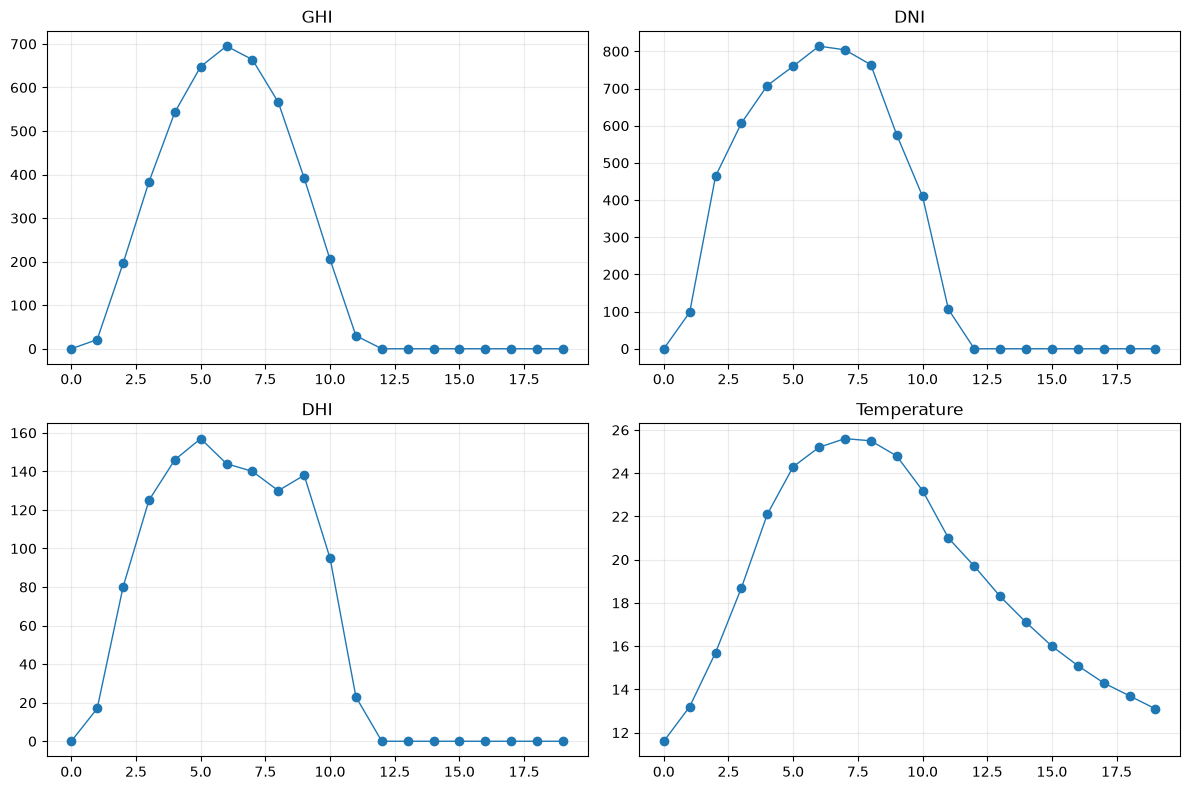


Relevant field summary:


,count,mean,std,min,25%,50%,75%,max
Temperature,8760.0,25.612260,5.658848,8.0,22.4,26.7,29.30,41.1
Clearsky DHI,8760.0,89.590297,113.800257,0.0,0.0,5.0,168.00,500.0
Clearsky DNI,8760.0,238.882420,289.764862,0.0,0.0,2.0,512.00,881.0
Clearsky GHI,8760.0,251.109475,324.232722,0.0,0.0,5.0,533.00,983.0
DHI,8760.0,102.466438,136.950826,0.0,0.0,3.0,198.25,509.0
DNI,8760.0,157.163014,234.083241,0.0,0.0,0.0,306.00,877.0
GHI,8760.0,205.433105,283.408201,0.0,0.0,3.0,408.00,961.0
Pressure,8760.0,1006.713014,6.185847,991.0,1001.0,1007.0,1012.00,1020.0


In [7]:
# Quick visual check for the main solar metrics.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, ["GHI", "DNI", "DHI", "Temperature"]):
    if col in df.columns:
        ax.plot(df[col].dropna().head(20), marker='o', linewidth=1)
        ax.set_title(col)
        ax.grid(alpha=0.25)
    else:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{col} not in columns", ha='center', va='center')
plt.tight_layout()
plt.show()

# A compact summary of the most relevant solar features.
summary = df[[c for c in df.columns if c in ["Latitude", "Longitude", "Elevation", "Temperature", "Pressure", "GHI", "DNI", "DHI", "Clearsky GHI", "Clearsky DNI", "Clearsky DHI"]]].copy()
print("\nRelevant field summary:")
display(summary.describe(include="all").T)


## EDA Findings

- The dataset contains 8,760 rows and 2,034 columns, representing one full year of hourly NSRDB data for Bangladesh in 2019.
- The data includes time-related variables together with meteorological, solar radiation, atmospheric, photovoltaic, and spectral features.
- The main solar variables such as GHI, DNI, and DHI provide complete hourly observations, while some specialized fields contain missing values.
- Duplicate-row checking shows that the dataset contains no duplicate records.
- The average temperature is approximately 25.61°C, while the average GHI, DNI, and DHI are approximately 205.43, 157.16, and 102.47 respectively.
- The large number of spectral wavelength features makes the dataset highly dimensional and provides detailed information about solar radiation across different wavelengths.
- Overall, the 2019 dataset is a detailed hourly solar and weather dataset suitable for temporal analysis, solar-resource assessment, feature engineering, and predictive modeling.